<a href="https://colab.research.google.com/github/Anannya-Vyas/MACHINE-LEARNING-FROM-SCRATCH-/blob/main/SVM_on_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BUILT BY ANANNYA VYAS AS IN JOURNEY OF LEARNING ML. thanks to my teachers and parents and friends and internet members

# ** SVM (Support vector Machine)**

This notebook demonstrates the use of Support Vector Machines (SVMs) for classification tasks. SVMs are powerful supervised learning models used for classification and regression analysis.

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ignore any warning messages to keep the output clean.

In [ ]:
import pandas as pd # Import the pandas library for data manipulation (e.g., creating DataFrames).
from sklearn.datasets import load_iris # Import the Iris dataset, a classic dataset for classification.

iris = load_iris() # Load the Iris dataset.
len(iris) # Check the number of attributes in the Iris dataset object.

8

In [ ]:
print(iris.feature_names,iris.target_names) # Print the names of the features (input variables) and target classes (output labels) in the Iris dataset.

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


In [ ]:
Data = pd.DataFrame(iris.data,columns=iris.feature_names) # Create a pandas DataFrame from the Iris features, using the feature names as column headers.
Data.head() # Display the first few rows of the DataFrame to inspect the data.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
Data['target'] = iris.target # Add a new column named 'target' to the DataFrame, containing the numerical target labels (0, 1, or 2).
Data.head() # Display the DataFrame again to see the new 'target' column.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
Data[Data.target==1].head() # Filter the DataFrame to show only rows where the 'target' is 1 (which corresponds to 'versicolor'), and display the first few of these rows.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [ ]:
Data[Data.target==2].head() # Filter the DataFrame to show only rows where the 'target' is 2 (which corresponds to 'virginica'), and display the first few of these rows.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [ ]:
Data['Label'] =Data.target.apply(lambda x: iris.target_names[x]) # Create a new 'Label' column that maps the numerical target (0, 1, 2) to its corresponding flower name ('setosa', 'versicolor', 'virginica').
Data.head() # Display the DataFrame to see the new 'Label' column.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Label
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
from sklearn.model_selection import train_test_split # Import the function to split data into training and testing sets.

In [ ]:
X = Data.drop(['target','Label'], axis='columns') # Create feature set (X) by dropping the 'target' and 'Label' columns from the DataFrame.
y = Data.target # Create target variable (y) using the 'target' column.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # Split the data into training (80%) and testing (20%) sets. X_train and y_train are for training the model, X_test and y_test are for evaluating it.

In [ ]:
from sklearn.svm import SVC # Import the Support Vector Classifier (SVC) model.
model = SVC() # Create an instance of the SVC model with default parameters.
model.fit(X_train, y_train) # Train the model using the training features (X_train) and training labels (y_train).

In [ ]:
model.fit(X_train, y_train) # This line re-trains the model. It's redundant if the model was already trained in the previous cell.

SVC()

In [ ]:
model.score(X_test, y_test) # Evaluate the model's accuracy on the test set. This shows how well the model generalizes to unseen data.

0.9666666666666667

In [ ]:
model.predict([[4.8,3.0,1.5,0.3]]) # Use the trained model to predict the class for a new, unseen data point with specified feature values.

array([0])

In [ ]:
model_1 = SVC(C=1,kernel='linear') # Create another SVC model with a linear kernel and regularization parameter C=1.
model_1.fit(X_train, y_train) # Train this new model.
model_1.score(X_test, y_test) # Evaluate its accuracy on the test set.

0.9666666666666667

In [ ]:
model_2 = SVC(C=10,gamma=10,kernel='linear') # Create an SVC model with C=10, gamma=10, and a linear kernel. 'gamma' is a parameter for non-linear kernels but is specified here even for a linear kernel.
model_2.fit(X_train, y_train) # Train this model.
model_2.score(X_test, y_test) # Evaluate its accuracy.

0.9333333333333333

In [ ]:
model_3 = SVC(C=1,gamma=10) # Create an SVC model with C=1 and gamma=10. By default, this uses an 'rbf' (Radial Basis Function) kernel.
model_3.fit(X_train, y_train) # Train this model.
model_3.score(X_test, y_test) # Evaluate its accuracy.

0.9333333333333333

In [ ]:
model_4 = SVC(C=3) # Create an SVC model with C=3. By default, this uses an 'rbf' kernel.
model_4.fit(X_train, y_train) # Train this model.
model_4.score(X_test, y_test) # Evaluate its accuracy.

0.9666666666666667

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay # Import ConfusionMatrixDisplay to visualize the performance of a classification model.

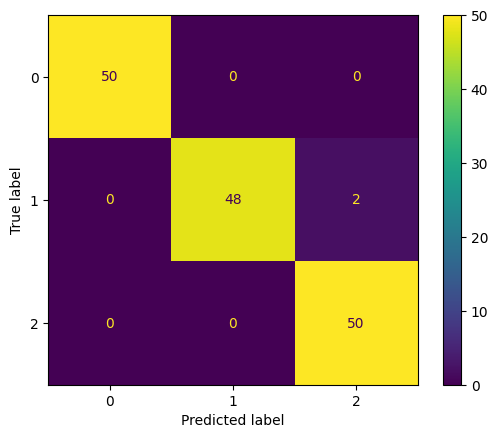

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_1, X, y) # Display the confusion matrix for 'model_1' using the full dataset (X, y). A confusion matrix shows how many predictions were correct and incorrect for each class.

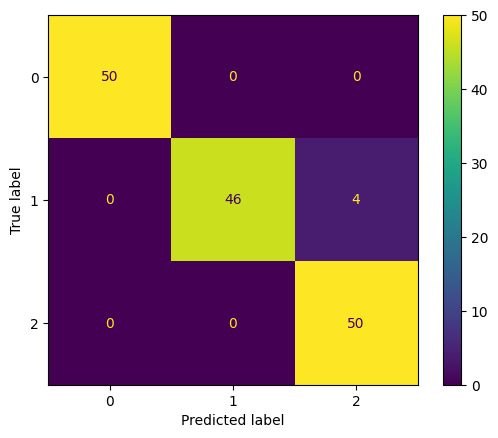

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_2, X, y) # Display the confusion matrix for 'model_2' using the full dataset.

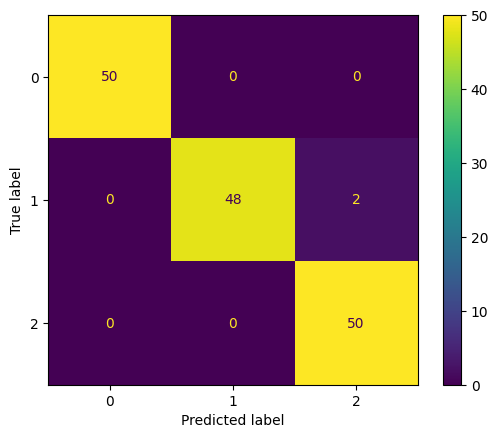

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_3, X, y) # Display the confusion matrix for 'model_3' using the full dataset.

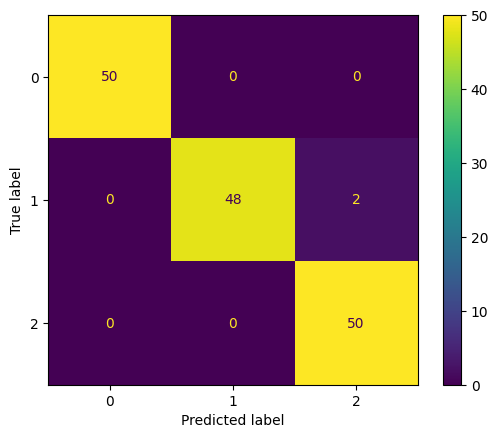

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_4, X, y) # Display the confusion matrix for 'model_4' using the full dataset.

In [ ]:
from sklearn.datasets import load_digits # Import the Digits dataset, another common dataset for classification (handwritten digits).

In [ ]:
digits=load_digits() # Load the Digits dataset.

In [ ]:
df=pd.DataFrame(digits.data) # Create a pandas DataFrame from the digits feature data.

In [ ]:
df['target']=digits.target # Add a 'target' column to the DataFrame, containing the numerical labels for each digit.
df.head() # Display the first few rows of the Digits DataFrame.

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
from sklearn.model_selection import train_test_split # Re-importing the train_test_split function.
x=df.drop(['target'],axis='columns') # Create feature set (x) for the digits data by dropping the 'target' column.
y=df.target # Create target variable (y) for the digits data.
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=12) # Split the digits data into training and testing sets, with a fixed random_state for reproducibility.

In [ ]:
from sklearn.metrics import accuracy_score # Import accuracy_score for evaluating classification models.

In [ ]:
from sklearn.svm import SVC # Import the Support Vector Classifier (SVC) model.
model1=SVC(kernel='rbf',C=10) # Create an SVC model with a Radial Basis Function (RBF) kernel and regularization parameter C=10.
model1.fit(x_train,y_train) # Train this model using the digits training data.

SVC(C=10)

In [ ]:
y_pred_1=model1.predict(x_test) # Make predictions on the digits test set using 'model1'.
print("Model Score of Kernal(rbf) :", model1.score(x_test,y_test)) # Print the accuracy score of 'model1' on the digits test set.

Model Score of Kernal(rbf) : 0.9944444444444445


Let's perform hyperparameter tuning for the SVC model on the digits dataset using `GridSearchCV` to find the optimal parameters. We'll explore different kernels ('rbf', 'linear', 'poly') and regularization parameters (C).

Hyperparameter tuning is the process of finding the best set of hyperparameters for a machine learning model to optimize its performance. `GridSearchCV` systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which values provide the best performance.

In [ ]:
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for hyperparameter tuning.

param_grid = { # Define the grid of parameters to search.
    'C': [0.1, 1, 10, 100], # Regularization parameter. Smaller values specify stronger regularization.
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1], # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    'kernel': ['rbf', 'linear', 'poly'] # Type of kernel function to use.
}

svc_grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5, n_jobs=-1) # Create a GridSearchCV object.
# SVC(): The estimator to tune.
# param_grid: The parameters to try.
# refit=True: Refit an estimator with the best found parameters on the whole dataset.
# verbose=3: Show a detailed progress log.
# cv=5: Use 5-fold cross-validation.
# n_jobs=-1: Use all available CPU cores for parallel processing.

svc_grid.fit(x_train, y_train) # Run the grid search on the training data.

print("Best Parameters found:", svc_grid.best_params_) # Print the combination of parameters that yielded the best score.
print("Best Estimator Score:", svc_grid.best_score_) # Print the cross-validated score of the best estimator.

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters found: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Best Estimator Score: 0.9916448896631824


Now, let's evaluate the best model found by `GridSearchCV` on the test set and display its confusion matrix.

Evaluating the best model on unseen test data provides an unbiased estimate of its performance, and the confusion matrix helps visualize where the model makes mistakes.

Accuracy of the best SVM model on the test set: 0.9944


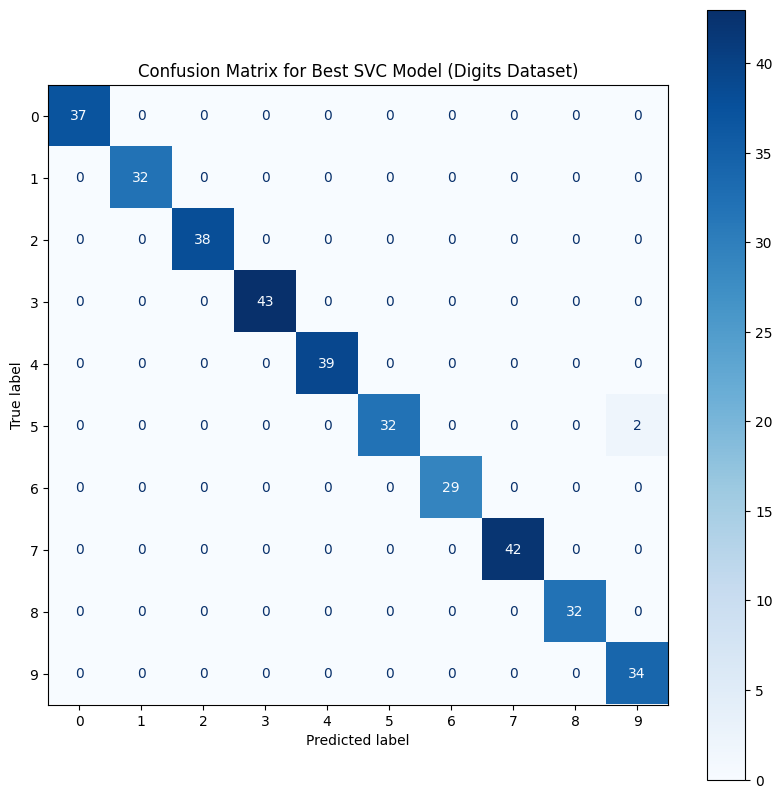

In [ ]:
best_svc_model = svc_grid.best_estimator_ # Get the best performing SVC model from the GridSearchCV result.
accuracy = best_svc_model.score(x_test, y_test) # Calculate the accuracy of the best model on the test set.
print(f"Accuracy of the best SVM model on the test set: {accuracy:.4f}") # Print the accuracy, formatted to 4 decimal places.

from sklearn.metrics import ConfusionMatrixDisplay # Import ConfusionMatrixDisplay for plotting.
import matplotlib.pyplot as plt # Import matplotlib for plotting.

fig, ax = plt.subplots(figsize=(10, 10)) # Create a figure and an axes object for the plot.
ConfusionMatrixDisplay.from_estimator(best_svc_model, x_test, y_test, cmap=plt.cm.Blues, ax=ax) # Plot the confusion matrix for the best model using the test data.
# cmap=plt.cm.Blues: Use a blue color map for the matrix.
# ax=ax: Draw the plot on the created axes.
plt.title('Confusion Matrix for Best SVC Model (Digits Dataset)') # Set the title of the confusion matrix plot.
plt.show() # Display the plot.

In [ ]:
model2=SVC(kernel='linear') # Create another SVC model, this time specifically using a 'linear' kernel.
model2.fit(x_train,y_train) # Train this linear kernel model on the digits training data.


SVC(kernel='linear')

In [ ]:
y_pred_2=model2.predict(x_test) # Make predictions on the digits test set using 'model2'.
print("Model Score of Kernal(linear) :", model2.score(x_test,y_test)) # Print the accuracy score of the linear kernel model on the digits test set.

Model Score of Kernal(linear) : 0.975
